# 📊 Análise de Desempenho dos Mapas da FURIA
Este notebook tem como objetivo analisar o desempenho da equipe FURIA em diferentes mapas com base no winrate (% de vitórias).

Além da análise exploratória, serão aplicados modelos de Machine Learning para classificar o desempenho dos mapas e comparar diferentes abordagens de modelagem.# Nova seção

# 🧠 Contexto
No cenário competitivo, entender quais mapas apresentam melhor desempenho é essencial para a tomada de decisão estratégica.

Neste projeto, utilizamos dados de winrate para:

Classificar os mapas em níveis de desempenho
Identificar padrões nos dados
Comparar modelos de Machine Learning

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

#📂 Dataset
O dataset contém o winrate (%) da equipe FURIA em diferentes mapas.

Esses dados serão utilizados como base para análise e modelagem.

In [15]:
df = pd.DataFrame({
    'Map': ['Overpass', 'Vertigo', 'Mirage', 'Nuke', 'Inferno', 'Anubis', 'Ancient', 'Dust2'],
    'Winrate%': [61.2, 61.2, 60.1, 57.8, 59.0, 50, 50.7, 60.2],
})

df

,Map,Winrate%
0,Overpass,61.2
1,Vertigo,61.2
2,Mirage,60.1
3,Nuke,57.8
4,Inferno,59.0
5,Anubis,50.0
6,Ancient,50.7
7,Dust2,60.2


# ⚙️ Processamento dos Dados
Para analisar o desempenho, foi criada uma classificação baseada na média do winrate.

Essa abordagem permite dividir os mapas em três categorias:

High (alto desempenho)
Medium (desempenho médio)
Low (baixo desempenho)

In [ ]:
average_winrate = np.mean(df['Winrate%'])

df['Performance'] = df['Winrate%'].apply(
    lambda x: 'High' if x > average_winrate + 2 else (
        'Low' if x < average_winrate - 1 else 'Medium'
    )
)

df = df.sort_values(by='Winrate%', ascending=False)

df

# 📈 Visualização dos Dados
O gráfico abaixo mostra o desempenho por mapa, com cores indicando a classificação.

A linha tracejada representa a média de winrate.

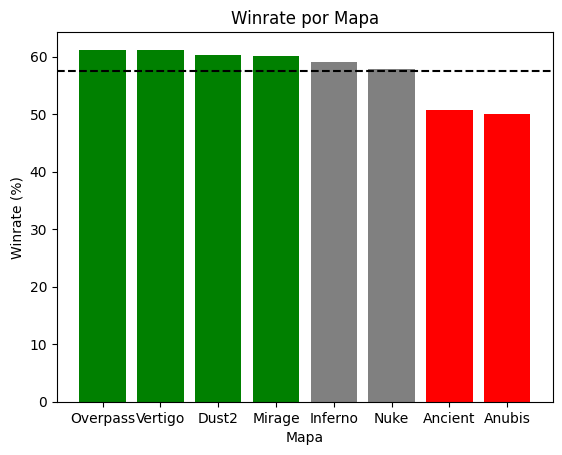

In [17]:
colors = df['Performance'].map({
    'High': 'green',
    'Medium': 'gray',
    'Low': 'red',
})

plt.bar(df['Map'], df['Winrate%'], color=colors)
plt.axhline(average_winrate, linestyle='--', color='black')
plt.title('Winrate por Mapa')
plt.xlabel('Mapa')
plt.ylabel('Winrate (%)')
plt.show()

# 🤖 Modelos de Machine Learning
Serão utilizados dois modelos para classificar o desempenho:

Regressão Logística → baseada em probabilidade e tendência
Árvore de Decisão → baseada em regras e limites
O objetivo é comparar como cada modelo interpreta os dados.

In [ ]:
X = df[['Winrate%']]
y = df['Performance']

model = LogisticRegression()
model.fit(X, y)

tree = DecisionTreeClassifier()
tree.fit(X, y)

# 🔍 Teste de Previsão
Será utilizado um valor próximo da média para observar o comportamento dos modelos.

In [19]:
test = [[59.5]]

print("Logistic:", model.predict(test))
print("Tree:", tree.predict(test))

Logistic: ['High']
Tree: ['Medium']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


#🧠 Análise dos Resultados
Foi observada uma divergência entre os modelos para valores próximos à média.

Para um winrate de 59.5%:

Regressão Logística → High
Árvore de Decisão → Medium
Essa diferença ocorre porque:

A Regressão Logística considera a tendência geral dos dados
A Árvore de Decisão utiliza limites fixos
Isso evidencia a existência de uma zona de incerteza nos dados.

#📌 Conclusão
Este projeto demonstrou como a análise de dados e modelos de Machine Learning podem ser utilizados para apoiar decisões.

Além disso, mostrou que diferentes modelos podem apresentar comportamentos distintos, especialmente próximos às fronteiras de decisão.

Portanto, valores próximos da média devem ser analisados com cautela.